In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False
    print('ipywidgets not available — interactive cells will show static figures')

print('numpy', np.__version__, '| widgets:', HAS_WIDGETS)
rng = np.random.default_rng(0)

# --- two datasets: classification (perceptron as classifier) + regression (perceptron as linear unit) ---
n = 200
Xc = rng.uniform(-5, 5, size=(n, 2))
yc = ((Xc[:, 0] + 0.7 * Xc[:, 1] - 1.0 + rng.normal(0, 1.0, size=n)) > 0).astype(int)  # 0/1 labels
Xr = rng.uniform(0, 10, size=(n, 2))
w_true = np.array([2.5, -1.8]); b_true = 4.0
yr = b_true + Xr[:, 0] * w_true[0] + Xr[:, 1] * w_true[1] + rng.normal(0, 2.0, size=n)
print('classification:', Xc.shape, yc.shape, '| regression:', Xr.shape, yr.shape)


numpy 1.21.2 | widgets: True
classification: (200, 2) (200,) | regression: (200, 2) (200,)


# АКТ 1: Что такое ваш персептрон?
## Архитектура персептрона

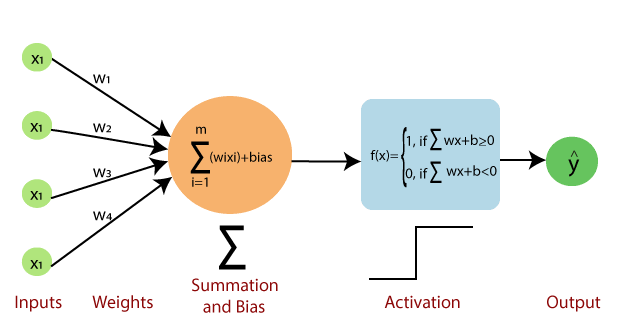

- $\large{x_1,x_2,...,x_n}$: входы, признаки конкретного объекта в данных
- $\large{w_1,w_2,...,w_n}$: веса, показывают важность влияния признака на предсказания
- $\large{b}$: отступ от начала координат
- $\large{\hat{y}}$: предсказание
- $\large{\phi}$: функция активации

$$\large{\hat{y} = \phi (\sum_{i=1}^n x_i w_i + b)}$$

NameError: name 's' is not defined

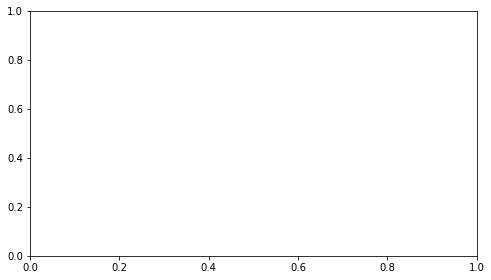

In [2]:
# FIGURE: perceptron wiring diagram (left) + the two heads: step vs linear (right).
fig, axes = plt.subplots(1, 1, figsize=(8, 4.5))
axes.plot(s, (s > 0).astype(float), label='step head (classifier): 0 or 1')
axes.set_xlabel('score s'); ax.set_ylabel('answer ŷ')
axes.set_title('The two heads: step jumps, linear copies')
axes.legend(); axes.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
# INTERACTIVE: move w1, w2, b sliders and watch the line move. Static fallback if no widgets.
def draw_boundary(w1=1.0, w2=0.7, b=-1.0):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(Xc[yc == 0, 0], Xc[yc == 0, 1], alpha=0.5, label='class 0')
    ax.scatter(Xc[yc == 1, 0], Xc[yc == 1, 1], alpha=0.5, label='class 1')
    xs = np.linspace(-5, 5, 100)
    if abs(w2) > 1e-9:
        ax.plot(xs, -(b + w1 * xs) / w2, 'k-', lw=2)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(f'w1={w1:.2f} w2={w2:.2f} b={b:.2f}  →  line moves!')
    ax.legend(); ax.set_aspect('equal', adjustable='box'); plt.tight_layout(); plt.show()

if HAS_WIDGETS:
    widgets.interact(draw_boundary,
        w1=widgets.FloatSlider(value=1.0, min=-2, max=2, step=0.1, description='w1'),
        w2=widgets.FloatSlider(value=0.7, min=-2, max=2, step=0.1, description='w2'),
        b=widgets.FloatSlider(value=-1.0, min=-5, max=5, step=0.2, description='b'))
else:
    draw_boundary()


## Вектора внутри персептрона

Возьмем функцию предсказания

$$\large{\hat{y} = \phi (\sum_{i=1}^n x_i w_i + b)}$$

Посмотрим на выражение под функцией активации

$$\large{x = w_1 x_1 + w_2 x_2 + \dots + x_n + b}$$

Перепишем x как вектор

$$x = \begin{bmatrix}
           x_{1} \\
           x_{2} \\
           \vdots \\
           x_{m}
         \end{bmatrix}$$ 
         
Перепишем w как вектор
         
$$w = \begin{bmatrix}
w_{1} \\
w_{2} \\
\vdots \\
w_{m}
\end{bmatrix}$$

z - это скалярное произведение векторов + отступ b

$$\large{z = w^Tx + b}$$

## Косинусная близость

Так же скалярное произведение это:

$$\large{z = |w|\,|x|\cos\theta + b}$$

In [ ]:
w = np.array([1.0, 0.7]); b = -1.0
x = np.array([3.0, 1.0])
proj_len = x.dot(w) / w.dot(w)  # signed length factor along w
proj = proj_len * w

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# left: projection
ax = axes[0]
ax.arrow(0, 0, w[0], w[1], head_width=0.2, length_includes_head=True, color='k', lw=2, label='w')
ax.arrow(0, 0, x[0], x[1], head_width=0.2, length_includes_head=True, color='tab:blue', lw=2, label='x')
ax.arrow(0, 0, proj[0], proj[1], head_width=0.15, length_includes_head=True, color='tab:orange', lw=2, linestyle='--', label='projection of x on w')
ax.plot([x[0], proj[0]], [x[1], proj[1]], ':', color='gray')
ax.set_title(f'w·x = {x.dot(w):.2f}, cos = {x.dot(w) / (np.linalg.norm(x)*np.linalg.norm(w)):.2f}')
ax.legend(); ax.set_aspect('equal', adjustable='box'); ax.grid(True, alpha=0.3)
# right: score heatmap
ax = axes[1]
g = np.linspace(-5, 5, 200); G1, G2 = np.meshgrid(g, g)
S = b + w[0] * G1 + w[1] * G2
im = ax.imshow(S, extent=(-5, 5, -5, 5), origin='lower', cmap='coolwarm', alpha=0.9)
ax.contour(G1, G2, S, levels=[0], colors='k', linewidths=2)
ax.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap='coolwarm', edgecolors='k', s=12, alpha=0.6)
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_title('Score s = w·x + b everywhere (black line: s = 0)')
plt.colorbar(im, ax=ax, label='score s'); plt.tight_layout(); plt.show()


Что наглядно видно на графиках:

- **проекция:** $\mathrm{proj}_w(x) = \frac{w\cdot x}{|w|^2}\,w$ — тень от $x$ на $w$ (оранжевая стрелка);
- **близость:** $\cos\theta = \frac{w\cdot x}{|w||x|}$ is $+1$ (одно направление) → $0$ (перпендикуляр) → $-1$ (обратное направление);
- **side + distance:** $\mathrm{sign}(s)$ tells which side of the line the point is on;
  $|z|/|w|$ перпендикуляр **расстояние** до линии $z = 0$;
- **bias** $b$ перемещает нулевую линию z таким образом что $w\cdot x > -b$ выше линии.

Таким образом персептрон показывает геометрически: *достаточно ли лежит точка $x$ в одном направление относительно вектора $w$ чтобы пересечь границу $-b$?*
Левая фигура: Стрелки проекций. Правая фигура: Поле оценко $z(x)$ на всей плоскости (черная прямая = $z = 0$).

In [ ]:
# FIGURE: cosine similarity vs angle — the dot product as 'direction agreement'.
angs = np.array([0, 30, 60, 90, 120, 150, 180])
w2v = np.array([1.0, 0.0])
dots, coss = [], []
for a in angs:
    r = np.deg2rad(a); x2v = np.array([np.cos(r), np.sin(r)])
    dots.append(w2v.dot(x2v)); coss.append(w2v.dot(x2v) / (np.linalg.norm(w2v) * np.linalg.norm(x2v)))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar([str(a) + '°' for a in angs], coss, color='teal', alpha=0.7)
axes[0].set_xlabel('angle θ between w and x'); axes[0].set_ylabel('cos θ = (w·x)/(|w||x|)')
axes[0].set_title('From +1 (same way) through 0 (⊥) to −1 (opposite)')
axes[1].axis('equal'); axes[1].set_xlim(-1.3, 1.3); axes[1].set_ylim(-1.3, 1.3)
axes[1].arrow(0, 0, 1, 0, head_width=0.07, color='k', lw=2); axes[1].text(1.02, 0.05, 'w')
for a, c in zip(angs[::2], ['tab:blue', 'tab:orange', 'tab:green', 'red']):
    r = np.deg2rad(a)
    axes[1].arrow(0, 0, np.cos(r), np.sin(r), head_width=0.06, color=c, lw=2)
    axes[1].text(1.1 * np.cos(r), 1.1 * np.sin(r), f'{a}°', color=c)
axes[1].set_title('Same arrows on the unit circle'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


# АКТ 2: Как обучать персептрон

## Зачем нам функция потерь

Линия $z=0$ может быть проведена некорректно в бесконечном количестве вариантов — нам нужно **одно число** которые показывает *как плохи параметры $(b, w_1, w_2)$?*
Это число - это функция потерь $L$. Требования: выход функции одно число, чем больше тем лучше, достаточно гладкая. Например

$$\large{L_{MSE} = \frac{1}{n}\sum_{i=1}^n (\hat y_i - y_i)^2}$$

- **Количество ошибок** ($L_{01}$) Звучит логично, однако бесполезно математически: плоская функция с прыжками,
  нет *направления уменьшия* ошибки;
- **MSE**: большие ошибки действуют в квадрате, небольшие становятся в квадрат меньше;
  остатки $r_i = \hat y_i - y_i$ (левый график) взяты под корень и усреднены;

График в конце фиксирует $w$ и изменяет только $b$

In [ ]:
# Left: residuals as stems (who is wrong). Right: 0-1 step vs MSE bowl (why smooth loss wins).
w0 = np.array([1.0, -1.0]); b0 = 0.0
pred0 = Xr @ w0 + b0
idx = np.argsort(yr)[:40]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.scatter(yr[idx], pred0[idx], alpha=0.7, label='predictions')
for t, p in zip(yr[idx], pred0[idx]):
    ax.plot([t, t], [t, p], color='gray', alpha=0.5)
mn, mx = yr.min(), yr.max(); ax.plot([mn, mx], [mn, mx], 'r--', label='ideal')
ax.set_xlabel('true y'); ax.set_ylabel('predicted'); ax.set_title('Residuals = vertical stems to the ideal line'); ax.legend()
ax = axes[1]
s = np.linspace(-3, 3, 400)
zero_one = (np.abs(s) > 0.5).astype(float)
mse_curve = s ** 2
ax.plot(s, zero_one, label='0-1 loss (flat, jumps, no slope)')
ax.plot(s, mse_curve / 4, label='MSE / 4 (smooth bowl, slope → home)')
ax.set_xlabel('residual (ŷ − y)'); ax.set_ylabel('loss'); ax.set_title('Why MSE: it points downhill, 0-1 does not')
ax.legend(); plt.tight_layout(); plt.show()


In [ ]:
# The loss as a function of ONE parameter (bias b, weights fixed): a perfect bowl with one bottom.
bs = np.linspace(-5, 15, 200)
J = np.array([np.mean((Xr @ w_true + b_ - yr) ** 2) for b_ in bs])
plt.figure(figsize=(7, 4))
plt.plot(bs, J)
plt.scatter([b_true], [J[np.argmin(np.abs(bs - b_true))]], c='r', zorder=5, label='bottom ≈ true b')
plt.xlabel('bias b (w fixed)'); plt.ylabel('MSE loss J'); plt.title('Loss landscape in 1D: slide b until the bowl bottom')
plt.legend(); plt.tight_layout(); plt.show()


## Зачем нам производные?

Функция потерь $L(b, w_1, w_2)$ это чашка. **Производная это наклон стенок чашки**:

$$\frac{dJ}{db} = \lim_{h\to 0}\frac{J(b+h) - J(b-h)}{2h}, \qquad
\frac{\partial J}{\partial w_1}\;\text{= slope along } w_1 \text{ holding the rest fixed}$$

- наклон $> 0$ → функция растет → шагаем **влево** (уменьшить параметр);
- наклон $< 0$ → функция падает → шагаем **вправо**;
- наклон $= 0$ → гладкая поверхность → минимум (или седло (поговорим позже)), останавливаемся.

Производная сложной функции $(\hat y_i - y_i)^2$, где $\hat y_i = b + w_1 x_{i1} + w_2 x_{i2}$

$$g_b = \frac{2}{n}\sum(\hat y_i - y_i), \quad
g_1 = \frac{2}{n}\sum(\hat y_i - y_i)x_{i1}, \quad
g_2 = \frac{2}{n}\sum(\hat y_i - y_i)x_{i2}$$

Обучение = *измеряем три наклона, шагаем в обратную сторону от наклона*. Если нет производной, не понятно как уменьшать функцию;
С производной → (почти) каждый шаг улучшает. Геометрическая интерпретация касательной доказывает, что аналитический наклон равен численному наклону. $(J(b+h)-J(b-h))/2h$; На рисунке, показывающем разные признаки, видно, что каждая частная производная представляет собой лишь одномерный наклон соответствующей «чаши».


In [ ]:
# Slope tells the direction: tangent arrows on a 1D bowl + numeric check of the analytic slope.
bs = np.linspace(-5, 15, 200)
J = np.array([np.mean((Xr @ w_true + b_ - yr) ** 2) for b_ in bs])
b_at = 11.0
pred_at = Xr @ w_true + b_at
slope = 2 * np.mean(pred_at - yr)  # dJ/db, scalar formula from Seminar 2
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bs, J, label='J(b)')
J_at = np.mean((pred_at - yr) ** 2)
ax.scatter([b_at], [J_at], c='r', s=60, zorder=5)
tb = np.linspace(b_at - 3, b_at + 3, 50)
ax.plot(tb, J_at + slope * (tb - b_at), 'r--', label=f'tangent, slope={slope:.2f} → step left')
ax.annotate('', xy=(b_at - 2, J_at + slope * -2), xytext=(b_at, J_at),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.set_xlabel('b'); ax.set_ylabel('J'); ax.set_title('Derivative = slope. It says WHERE downhill is.')
ax.legend(); plt.tight_layout(); plt.show()
# numeric check: (J(b+e) - J(b-e)) / 2e ≈ analytic slope
e = 1e-5
num = (np.mean((Xr @ w_true + b_at + e - yr) ** 2) - np.mean((Xr @ w_true + b_at - e - yr) ** 2)) / (2 * e)
print(f'analytic slope: {slope:.6f} | numeric slope: {num:.6f} | match: {np.isclose(slope, num)}')


In [ ]:
# FIGURE: partial derivatives are 1-D slopes — slice the bowl along w1 and along w2.
mu_p, sig_p = Xr.mean(axis=0), Xr.std(axis=0)
Xp = (Xr - mu_p) / sig_p
w_ref = np.array([7.0, -5.0]); b_ref = float(np.mean(yr))
t1 = np.linspace(w_ref[0] - 10, w_ref[0] + 10, 200)
J1 = np.array([np.mean((b_ref + t * Xp[:, 0] + w_ref[1] * Xp[:, 1] - yr) ** 2) for t in t1])
t2 = np.linspace(w_ref[1] - 10, w_ref[1] + 10, 200)
J2 = np.array([np.mean((b_ref + w_ref[0] * Xp[:, 0] + t * Xp[:, 1] - yr) ** 2) for t in t2])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t1, J1); axes[0].scatter([w_ref[0]], [J1[np.argmin(np.abs(t1 - w_ref[0]))]], c='r', zorder=5)
axes[0].set_xlabel('w1 (w2, b fixed)'); axes[0].set_ylabel('J')
axes[0].set_title('Slice along w1: ∂J/∂w1 is this slope')
axes[1].plot(t2, J2, color='darkorange'); axes[1].scatter([w_ref[1]], [J2[np.argmin(np.abs(t2 - w_ref[1]))]], c='r', zorder=5)
axes[1].set_xlabel('w2 (w1, b fixed)'); axes[1].set_ylabel('J')
axes[1].set_title('Slice along w2: ∂J/∂w2 is this slope')
plt.tight_layout(); plt.show()


<a href="https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=gauss&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=1&seed=0.58251&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=regression&initZero=false&hideText=false">Визуализация тренировки</a>

## 6. Откуда взялся MSE? (Нормальный шум → least squares)

Предположим каждый ответ правдив, но имеет в себе нормальный шум:

$$y_i = \underbrace{b + w_1 x_{i1} + w_2 x_{i2}}_{\hat y_i} + \varepsilon_i,
\qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2), \quad
p(\varepsilon) = \frac{1}{\sqrt{2\pi}\sigma}e^{-\varepsilon^2/2\sigma^2}$$

**Производная в 4 линии.** Правдоподобность всех данных (точки независимы → вероятность независиммых переменных):

$$L = \prod_{i=1}^n \frac{1}{\sqrt{2\pi}\sigma}
e^{-(\hat y_i - y_i)^2 / 2\sigma^2}$$

Логарифм переводит произведение в сумму ($\log ab = \log a + \log b$):

$$\log L = -n\log(\sqrt{2\pi}\sigma) - \frac{1}{2\sigma^2}\sum_{i=1}^n (\hat y_i - y_i)^2$$

Первый множитель не имеет $(b, w_1, w_2)$; $\sqrt{2\pi\sigma^2} > 0$ только константы. Поэтому:

$$\max_{(b,w)} L \iff \min_{(b,w)} \sum_i (\hat y_i - y_i)^2
\iff \min \underbrace{\frac{1}{n}\sum_i (\hat y_i - y_i)^2}_{J_{MSE}}$$

**MSE соответствует оценке максимального правдоподобия в условиях гауссова шума.** — это не случайная функция
$\sigma$ не учитывается: лучшее решение одинаково для любого шума; меняется только значение функции потерь, *переменная* (≈ $\sigma^2$) изменяется.

- Слева: колокол (небольшие отклонения вероятны, значительные — редки). 
- Справа: остатки от истинной прямой подчиняются этому распределению.
- На третьем графике показаны зависимости $\log L$ и MSE от $b$: максимум одной величины приходится ровно на тот же уровень $b$, где другая достигает минимума.

In [ ]:
# Left: Gaussian bell — points near the line are likely, far ones unlikely. Right: residuals of a good line look Gaussian.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
t = np.linspace(-8, 8, 400); sig = 2.0
ax.plot(t, 1 / (np.sqrt(2 * np.pi) * sig) * np.exp(-t ** 2 / (2 * sig ** 2)))
ax.fill_between(t, 0, 1 / (np.sqrt(2 * np.pi) * sig) * np.exp(-t ** 2 / (2 * sig ** 2)), alpha=0.3)
ax.set_xlabel('residual (ŷ − y)'); ax.set_ylabel('probability density'); ax.set_title('Normal noise: small misses likely, big misses rare')
ax = axes[1]
resid = yr - (Xr @ w_true + b_true)
ax.hist(resid, bins=25, density=True, alpha=0.7, label='residuals of true line')
tt = np.linspace(resid.min(), resid.max(), 200)
ax.plot(tt, 1 / (np.sqrt(2 * np.pi) * sig) * np.exp(-tt ** 2 / (2 * sig ** 2)), 'r-', lw=2, label='N(0, σ²) bell')
ax.set_xlabel('residual'); ax.set_ylabel('density'); ax.set_title('Good line → residuals look like the bell'); ax.legend()
plt.tight_layout(); plt.show()
print(f'residual std: {np.std(resid):.2f} (true sigma = 2.0) — MSE ≈ σ² = {np.mean(resid**2):.2f}')


In [ ]:
# FIGURE: maximising log-likelihood == minimising MSE (mirror images, same optimum).
bs = np.linspace(-5, 15, 200); sig = 2.0
MSE = np.array([np.mean((Xr @ w_true + b_ - yr) ** 2) for b_ in bs])
logL = -len(yr) * np.log(np.sqrt(2 * np.pi) * sig) - np.sum(
    np.array([(Xr @ w_true + b_ - yr) ** 2 for b_ in bs]), axis=1) / (2 * sig ** 2)
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(bs, MSE, 'tab:blue', label='MSE (minimise →)')
ax1.set_xlabel('bias b (w fixed)'); ax1.set_ylabel('MSE', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(bs, logL, 'tab:red', label='log-likelihood (maximise →)')
ax2.set_ylabel('log L', color='tab:red')
ax1.set_title('Same optimum: MSE bottom = log-likelihood peak')
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper center')
plt.tight_layout(); plt.show()


## 7. Градиентный спуск для двух переменных — небольшие шаги вниз (только числа)

Наклоны, определяемые по MSE:

$$g_b = \frac{2}{n}\sum_{i=1}^n(\hat y_i - y_i), \quad
g_1 = \frac{2}{n}\sum_{i=1}^n(\hat y_i - y_i)x_{i1}, \quad
g_2 = \frac{2}{n}\sum_{i=1}^n(\hat y_i - y_i)x_{i2}$$

**Algorithm** (full-batch GD):

1. standardise features (same scale → same step works for both slopes);
2. start at $b = w_1 = w_2 = 0$;
3. repeat: $b := b - \alpha g_b,\; w_1 := w_1 - \alpha g_1,\; w_2 := w_2 - \alpha g_2$;
4. stop when $J$ flattens.

Размер шага $\alpha$ (скорость обучения): слишком маленькие шаги — медленно, хорошие - скольжения к низу,
слишком большие - взрыв и **расхождение** (потери резко возрастают — попробуйте lr = 1,5 в сравнении).

Рисунки: 3D-модель чаши с траекторией спуска, вид ее контура, падающая кривая потерь,
четыре скорости обучения рядом, и первые 8 шагов с аннотациями, чтобы вы могли увидеть зигзаг.
Перетащите ползунок, чтобы почувствовать переход ползание-скольжение-взрыв самостоятельно.

In [ ]:
# Scalar GD on STANDARDISED data (stable steps). Standardisation = broadcasting from Lecture 1 / Seminar 1.
mu, sigma = Xr.mean(axis=0), Xr.std(axis=0)
Xs = (Xr - mu) / sigma

def predict_scalar(X, w, b):
    return b + w[0] * X[:, 0] + w[1] * X[:, 1]

def gd_scalar(X, y, lr=0.1, n_iters=300):
    w = np.zeros(2); b = 0.0; hist = []; path = [(w.copy(), b)]
    for _ in range(n_iters):
        err = predict_scalar(X, w, b) - y
        g1 = 2 * np.mean(err * X[:, 0]); g2 = 2 * np.mean(err * X[:, 1]); gb = 2 * np.mean(err)
        w = w - lr * np.array([g1, g2]); b = b - lr * gb
        hist.append(np.mean((predict_scalar(X, w, b) - y) ** 2)); path.append((w.copy(), b))
    return w, b, np.array(hist), path

w_s, b_s, hist, path = gd_scalar(Xs, yr, lr=0.1, n_iters=300)
print(f'start MSE: {hist[0]:.2f} → end MSE: {hist[-1]:.2f} | w={np.round(w_s, 3)} b={b_s:.3f}')

# loss bowl on a grid around the path (vary w1, w2, keep b at solution)
a = np.linspace(w_s[0] - 12, w_s[0] + 12, 40); c = np.linspace(w_s[1] - 12, w_s[1] + 12, 40)
A, C = np.meshgrid(a, c)
J = np.array([[np.mean((predict_scalar(Xs, np.array([Aij, Cij]), b_s) - yr) ** 2) for Aij in a] for Cij in c])
pw = np.array([p[0] for p in path])

fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(A, C, J, alpha=0.6, edgecolor='none')
ax.plot(pw[1:, 0], pw[1:, 1], hist, 'r.-', ms=3, label='GD path downhill')
ax.set_xlabel('w1'); ax.set_ylabel('w2'); ax.set_zlabel('J'); ax.set_title('Bowl + downhill path'); ax.legend()
ax = fig.add_subplot(122)
ax.contour(A, C, J, levels=20)
ax.plot(pw[:, 0], pw[:, 1], 'r.-', ms=3)
ax.scatter([pw[0, 0]], [pw[0, 1]], c='k', s=60, label='start'); ax.scatter([pw[-1, 0]], [pw[-1, 1]], c='r', s=60, label='finish')
ax.set_xlabel('w1'); ax.set_ylabel('w2'); ax.set_title('Same path from above (contour map)'); ax.legend()
plt.tight_layout(); plt.show()
plt.figure(figsize=(6, 3.5)); plt.plot(hist); plt.xlabel('step'); plt.ylabel('MSE')
plt.title('Loss falls fast, then flattens — stop when flat'); plt.tight_layout(); plt.show()


In [ ]:
# Learning rate: too small crawls, good glides, too big explodes. Same code, different alpha.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for lr, ls in [(0.01, '-'), (0.1, '-'), (0.5, '-'), (1.5, '--')]:
    try:
        _, _, h, p = gd_scalar(Xs, yr, lr=lr, n_iters=100)
        ok = np.all(np.isfinite(h)) and h[-1] < 1e6
    except Exception:
        ok = False
    label = f'lr={lr}' + ('' if ok else ' (diverges!)')
    if ok:
        axes[0].plot(h, label=label, linestyle=ls); pp = np.array([q[0] for q in p])
        axes[1].plot(pp[:, 0], pp[:, 1], '.-', ms=3, label=label)
    else:
        axes[0].plot([], [], label=label)
axes[0].set_xlabel('step'); axes[0].set_ylabel('MSE (log)'); axes[0].set_yscale('log')
axes[0].set_title('Loss curves: pick the fast stable one'); axes[0].legend()
axes[1].set_xlabel('w1'); axes[1].set_ylabel('w2'); axes[1].set_title('Paths: crawl / glide / explode'); axes[1].legend()
plt.tight_layout(); plt.show()


In [ ]:
# INTERACTIVE: drag the learning-rate slider and see the loss curve + final MSE change.
def show_lr(lr=0.1):
    _, _, h, _ = gd_scalar(Xs, yr, lr=lr, n_iters=200)
    finite = np.all(np.isfinite(h)) and h[-1] < 1e6
    plt.figure(figsize=(6, 3.5))
    if finite: plt.plot(h)
    else: plt.text(0.5, 0.5, 'DIVERGED — loss exploded!', ha='center', transform=plt.gca().transAxes, fontsize=14, color='r')
    plt.xlabel('step'); plt.ylabel('MSE'); plt.title(f'lr={lr:.3f} → final MSE={h[-1] if finite else float("inf"):.3f}' if finite else f'lr={lr:.3f} → diverged')
    plt.tight_layout(); plt.show()

if HAS_WIDGETS:
    widgets.interact(show_lr, lr=widgets.FloatLogSlider(value=0.1, base=10, min=-3, max=0.3, description='lr'))
else:
    show_lr()


In [ ]:
# FIGURE: the first 8 GD steps on the contour + parameter traces converging.
mu_f, sig_f = Xr.mean(axis=0), Xr.std(axis=0)
Xf = (Xr - mu_f) / sig_f
def predict_f(X, w, b): return b + w[0] * X[:, 0] + w[1] * X[:, 1]
w, b, trace = np.zeros(2), 0.0, [(np.zeros(2), 0.0)]
for _ in range(8):
    err = predict_f(Xf, w, b) - yr
    w = w - 0.1 * np.array([2 * np.mean(err * Xf[:, 0]), 2 * np.mean(err * Xf[:, 1])])
    b = b - 0.1 * 2 * np.mean(err)
    trace.append((w.copy(), b))
a = np.linspace(-2, 9, 40); c = np.linspace(-9, 2, 40)
A, C = np.meshgrid(a, c)
Jc = np.array([[np.mean((predict_f(Xf, np.array([aa, cc]), b) - yr) ** 2) for aa in a] for cc in c])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].contour(A, C, Jc, levels=20)
pw8 = np.array([t[0] for t in trace])
axes[0].plot(pw8[:, 0], pw8[:, 1], 'r.-', ms=8)
for k in range(len(pw8)):
    axes[0].annotate(str(k), (pw8[k, 0], pw8[k, 1]), textcoords='offset points', xytext=(5, 5), fontsize=9, color='red')
axes[0].set_xlabel('w1'); axes[0].set_ylabel('w2')
axes[0].set_title('First 8 steps: numbered, zigzagging to the bottom')
tr = np.array([[t[0][0], t[0][1], t[1]] for t in trace])
axes[1].plot(tr[:, 0], label='w1'); axes[1].plot(tr[:, 1], label='w2'); axes[1].plot(tr[:, 2], label='b')
axes[1].set_xlabel('step'); axes[1].set_ylabel('value'); axes[1].set_title('Parameters settle after a few steps')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


# АКТ 3: Зачем нужны матрицы

## 3. Матрицы: те же уравнения, без сумм

Один объект (числовой):

$$\hat y_i = b + w_1 x_{i1} + w_2 x_{i2}$$

4 Объекта — **система линейных уравнений**

$$\begin{cases}
\hat y_1 = b + w_1 x_{11} + w_2 x_{12} \\
\hat y_2 = b + w_1 x_{21} + w_2 x_{22} \\
\hat y_3 = b + w_1 x_{31} + w_2 x_{32} \\
\hat y_4 = b + w_1 x_{41} + w_2 x_{42}
\end{cases}$$

Соберем строчки в таблицу $X$ размера $(n, 2)$ и ответы в $\hat y$ размера $(n,)$:

$$\hat y = X w + b, \qquad X \in \mathbb{R}^{n\times 2},\; w \in \mathbb{R}^{2}$$

$b$ **broadcasts**: то же значение добавляется в каждую строчку. Никакой новой математики —
только $n$ числовых уравнений обрабатываются вместе в быстром C loops вместо Python loops.
Изображение матрицы снизу показывается сетку с одной выделенной строкой: строка $i$ умножена на $w$ чтобы получить $\hat y_i$.
Проверка скоростей, показывает что матрицы сильно быстрее


In [ ]:
# Loop (scalars) vs matrix (one line): identical numbers, very different speed.
w = np.array([2.5, -1.8]); b = 4.0
n_small = Xr.shape[0]

pred_loop = np.array([b + w[0] * Xr[i, 0] + w[1] * Xr[i, 1] for i in range(n_small)])  # scalar thinking
pred_mat = Xr @ w + b                                                                # matrix thinking
print('max difference:', np.max(np.abs(pred_loop - pred_mat)))
assert np.allclose(pred_loop, pred_mat)

import time
Xbig = np.random.default_rng(1).uniform(0, 10, size=(200_000, 2))
t0 = time.time(); _ = Xbig @ w + b; t_mat = time.time() - t0
t0 = time.time(); _ = np.array([b + w[0] * r[0] + w[1] * r[1] for r in Xbig]); t_loop = time.time() - t0
print(f'matrix: {t_mat*1000:.1f} ms  vs  python loop: {t_loop*1000:.1f} ms  (x{t_loop/t_mat:.0f} faster)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(yr[:80], pred_mat[:80], alpha=0.7)
mn, mx = yr.min(), yr.max(); ax.plot([mn, mx], [mn, mx], 'r--', label='perfect prediction')
ax.set_xlabel('true y'); ax.set_ylabel('predicted ŷ = Xw + b'); ax.set_title('Batch prediction: one matrix line, n answers')
ax.legend(); plt.tight_layout(); plt.show()


In [ ]:
# FIGURE: the matrix as stacked scalar equations — one highlighted row dotted with w.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={'width_ratios': [1.1, 1]})
ax = axes[0]; ax.set_title('X (200×2): each row = one object, red = row 0'); ax.set_xlabel('feature j'); ax.set_ylabel('object i')
im = ax.imshow(Xr, aspect='auto', cmap='Blues')
ax.add_patch(plt.Rectangle((-0.5, -0.5), 2, 1, fill=False, ec='red', lw=2.5))
plt.colorbar(im, ax=ax, label='feature value')
ax.set_xticks([0, 1]); ax.set_xticklabels(['x1', 'x2'])
ax = axes[1]; ax.axis('off')
ax.set_title('Row 0 dotted with w gives ŷ0')
r0 = Xr[0]; w = np.array([2.5, -1.8]); b = 4.0
ax.text(0.05, 0.85, f'row 0:  x1={r0[0]:.2f},  x2={r0[1]:.2f}', fontsize=12, transform=ax.transAxes)
ax.text(0.05, 0.68, f'w = [{w[0]}, {w[1]}],  b = {b}', fontsize=12, transform=ax.transAxes)
ax.text(0.05, 0.50, f'ŷ0 = {b} + {w[0]}·{r0[0]:.2f} + ({w[1]})·{r0[1]:.2f} = {b + w[0]*r0[0] + w[1]*r0[1]:.2f}',
        fontsize=12, color='red', transform=ax.transAxes)
ax.text(0.05, 0.30, 'matrix line does this for ALL rows:', fontsize=11, transform=ax.transAxes)
ax.text(0.05, 0.16, 'ŷ = X @ w + b   (200 answers at once)', fontsize=13, family='monospace',
        bbox=dict(fc='lightyellow', ec='k'), transform=ax.transAxes)
plt.tight_layout(); plt.show()


## 8. Матричные производные — те же три наклона, одна прямая.

Никакой новой математики: **градиент** объединяет три скалярных наклона в один столбец.:

$$\nabla J = \begin{bmatrix} g_b \\ g_1 \\ g_2 \end{bmatrix},
\qquad J = \frac{1}{n}\|X_b\theta - y\|^2
\;\Rightarrow\;
\nabla J = \frac{2}{n}\, X_b^T\, (\underbrace{X_b\theta - y}_{\text{errors } e})$$

with $X_b = [\mathbf{1}, X]$ (одна колонка + признаки, размер $n\times 3$) и
$\theta = [b, w_1, w_2]^T$.

**От сумм к матричной записи** (одно и то же, три варианта обозначения):

$$g_1 = \frac{2}{n}\sum_i e_i x_{i1} = \frac{2}{n}\,(\text{column }1 \cdot e),
\qquad \nabla J = \frac{2}{n}\begin{bmatrix} \mathbf{1}\cdot e \\ x_1\cdot e \\ x_2\cdot e \end{bmatrix}$$

**Правило формы** (единственное, что нужно запомнить): производная от *числа* ($J$) *колонкой* ($\theta$)
это колонка того же размера. Проверим: $X_b^T$ это $3\times n$, $e$ is $n\times 1$ → градиент это $3\times 1$ ✓.

| $f(\theta)$ | $df/d\theta$ | used for |
|---|---|---|
| $a^T\theta$ | $a$ | linear head |
| $\|A\theta-y\|^2$ | $2A^T(A\theta-y)$ | MSE numerator |
| $\frac{1}{n}\|A\theta-y\|^2$ | $\frac{2}{n}A^T(A\theta-y)$ | our gradient |

Диаграмма распределения показывает поле $\nabla J(w_1, w_2)$: стрелок **вверх**, перпендикулярно контуру —
градиентный спуск двигается в обратном направлении. Bar chart разделяет одну стрелку $(g_b, g_1, g_2)$.


In [ ]:
# Gradient field: arrows = uphill (we walk opposite). Contours + one GD trajectory on top.
mu2, sigma2 = Xr.mean(axis=0), Xr.std(axis=0)
Xsn = (Xr - mu2) / sigma2
Xb = np.c_[np.ones(Xsn.shape[0]), Xsn]
yvec = yr

def J_of(t): return np.mean((Xb @ t - yvec) ** 2)
def grad_of(t): return (2 / Xb.shape[0]) * (Xb.T @ (Xb @ t - yvec))

g1 = np.linspace(-3, 16, 16); g2 = np.linspace(-12, 4, 16)
GG1, GG2 = np.meshgrid(g1, g2)
JJ = np.array([[J_of(np.array([6.6, a_, c_])) for a_ in g1] for c_ in g2])
U = np.zeros_like(GG1); V = np.zeros_like(GG2)
for i in range(GG1.shape[0]):
    for j in range(GG1.shape[1]):
        g = grad_of(np.array([6.6, GG1[i, j], GG2[i, j]]))
        U[i, j], V[i, j] = g[1], g[2]
fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(GG1, GG2, JJ, levels=25)
ax.quiver(GG1, GG2, U, V, color='tab:blue', alpha=0.7)
ax.set_xlabel('w1'); ax.set_ylabel('w2')
ax.set_title('Gradient field: arrows point uphill (⊥ contours). GD walks against them.')
plt.tight_layout(); plt.show()
t0 = np.zeros(3)
print('shape check: J scalar, θ', t0.shape, '→ grad', grad_of(t0).shape, '(same shape as θ ✓)')
print('scalar-vs-matrix gradient match:', np.allclose(grad_of(np.array([0.5, 1.0, -1.0]))[0], 2*np.mean(Xb @ np.array([0.5,1.0,-1.0]) - yvec)))


In [ ]:
# FIGURE: one gradient arrow decomposed into its three scalar slopes (same numbers as §7!).
mu_g, sig_g = Xr.mean(axis=0), Xr.std(axis=0)
Xg = (Xr - mu_g) / sig_g
Xbg = np.c_[np.ones(Xg.shape[0]), Xg]
th0 = np.array([1.0, 2.0, -1.0])
e0 = Xbg @ th0 - yr
g_mat = (2 / Xbg.shape[0]) * (Xbg.T @ e0)
g_b = 2 * np.mean(e0); g_1 = 2 * np.mean(e0 * Xg[:, 0]); g_2 = 2 * np.mean(e0 * Xg[:, 1])
print(f'matrix grad: {np.round(g_mat, 3)} | scalar slopes: [{g_b:.3f}, {g_1:.3f}, {g_2:.3f}] | match: {np.allclose(g_mat, [g_b, g_1, g_2])}')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['g_b (bias)', 'g_1 (w1)', 'g_2 (w2)'], [g_b, g_1, g_2], color=['gray', 'tab:blue', 'darkorange'], alpha=0.8)
axes[0].axhline(0, color='k', lw=1)
axes[0].set_title('One gradient = three scalar slopes (heights = step sizes × (−α))')
axes[0].set_ylabel('slope value')
for i, v in enumerate([g_b, g_1, g_2]):
    axes[0].text(i, v + (1 if v > 0 else -3), f'{v:.1f}', ha='center', fontsize=10)
axes[1].axis('off'); axes[1].set_title('Shape rule: (3×n)·(n×1) → (3×1)')
axes[1].text(0.05, 0.8, 'Xbᵀ : 3 × n   (transpose of data grid)', fontsize=12, family='monospace')
axes[1].text(0.05, 0.6, 'e   : n × 1   (one error per object)', fontsize=12, family='monospace')
axes[1].text(0.05, 0.4, '∇J  : 3 × 1   (one slope per parameter ✓)', fontsize=12, family='monospace',
             bbox=dict(fc='lightyellow', ec='k'))
axes[1].text(0.05, 0.15, 'd(number)/d(column) = column of the same shape', fontsize=11)
plt.tight_layout(); plt.show()


## 9. Градиентный спуск в матричной форме — одна линия вместо трех

Числовая версия:

$$b := b - \alpha g_b, \qquad w_1 := w_1 - \alpha g_1, \qquad w_2 := w_2 - \alpha g_2$$

Матричная версия (одна линия, **те же числа** — код снизу проверяет):

$$\theta := \theta - \alpha\,\nabla J
= \theta - \alpha\,\frac{2}{n}\, X_b^T (X_b\theta - y)$$

Зачем усложнять? Математика та же, но: одна строка вместо трех, никакого цикла Python по признакам,
код работает без изменений хоть для 2, хоть для 2000 признаков, и этот «диалект» понимают все библиотеки машинного обучения.
Итог: обе версии работают параллельно (кривые идеально совпадают), траектории параметров сходятся,
а аппроксимирующая плоскость $\hat y = b + w_1 x_1 + w_2 x_2$ земли рядом с истиной
$b = 4,\, w = [2.5, -1.8]$ (небольшой зазор = шум).


In [ ]:
# One-line update. Proof of equivalence + final 3D plane.
def gd_matrix(Xb_, y_, lr=0.1, n_iters=300):
    th = np.zeros(Xb_.shape[1]); hist = []; path = [th.copy()]
    for _ in range(n_iters):
        th = th - lr * (2 / Xb_.shape[0]) * (Xb_.T @ (Xb_ @ th - y_))  # THE one line
        hist.append(np.mean((Xb_ @ th - y_) ** 2)); path.append(th.copy())
    return th, np.array(hist), np.array(path)

th_m, hist_m, path_m = gd_matrix(Xb, yvec, lr=0.1, n_iters=300)
w_s2, b_s2, hist_s, path_s = gd_scalar(Xsn, yvec, lr=0.1, n_iters=300)
print(f'matrix θ=[b,w1,w2]: {np.round(th_m, 3)}')
print(f'scalar b={b_s2:.3f} w={np.round(w_s2, 3)}')
print('same path:', np.allclose(hist_m, hist_s), '| same weights:', np.allclose(th_m, np.r_[b_s2, w_s2]))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(hist_s, label='scalar (3 lines)'); ax.plot(hist_m, '--', label='matrix (1 line)')
ax.set_xlabel('step'); ax.set_ylabel('MSE'); ax.set_title('Identical curves — matrices just pack the sums')
ax.legend(); plt.tight_layout(); plt.show()

# back to original units + 3D plane
w_orig = th_m[1:] / sigma2; b_orig = th_m[0] - np.sum(th_m[1:] * mu2 / sigma2)
xx1 = np.linspace(Xr[:, 0].min(), Xr[:, 0].max(), 30); xx2 = np.linspace(Xr[:, 1].min(), Xr[:, 1].max(), 30)
G1, G2 = np.meshgrid(xx1, xx2); Gp = b_orig + w_orig[0] * G1 + w_orig[1] * G2
fig = plt.figure(figsize=(9, 6)); ax = fig.add_subplot(111, projection='3d')
ax.scatter(Xr[:, 0], Xr[:, 1], yr, alpha=0.4, label='data')
ax.plot_surface(G1, G2, Gp, alpha=0.5, edgecolor='none')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('y')
ax.set_title(f'Fitted plane (matrix GD): b={b_orig:.2f} w={np.round(w_orig, 2)} vs truth b=4 w=[2.5,-1.8]')
ax.legend(); plt.tight_layout(); plt.show()


In [ ]:
# FIGURE: parameter traces (matrix GD) + predicted-vs-true on held-out look.
th_hist = path_m  # (301, 3) from the gd_matrix run above: columns [b, w1, w2]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(th_hist[:, 0], label='b'); axes[0].plot(th_hist[:, 1], label='w1'); axes[0].plot(th_hist[:, 2], label='w2')
axes[0].set_xlabel('step'); axes[0].set_ylabel('value'); axes[0].set_title('Matrix GD: all three parameters settle together')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
yp = Xb @ th_m
axes[1].scatter(yp[::3], yvec[::3], alpha=0.6)
mn, mx = yvec.min(), yvec.max(); axes[1].plot([mn, mx], [mn, mx], 'r--', label='ideal')
axes[1].set_xlabel('predicted ŷ'); axes[1].set_ylabel('true y')
axes[1].set_title(f'Fit quality: RMSE={np.sqrt(np.mean((yp - yvec)**2)):.2f} ≈ σ=2.0'); axes[1].legend()
plt.tight_layout(); plt.show()


# Takeaway + self-check

**Одно предложение на секцию:** 
- Персептрон = взвешенная сумма + отступ; 
- Взвешенная сумма это скалярное произведение (проекция); 
- loss сжимает $n$ ошибок в одну чашу;
- Производные - наклон показывающий куда двигаться; 
- Гауссовый шум $\Rightarrow$ MSE; 
- GD = небольшие шаги в обратную сторону от среднего наклона по всем направлениям; 
- Матрицы сжимаются в $n$ сэмплов данных; 
- Градиент = Все наклоны одной точки в одной записи; 
- Матричный GD = Все наклоны в одной записи.


- [ ] Написать $z_i$, $g_b, g_1, g_2$, и $\theta$ обновление из памяти.
- [ ] Объяснить почему $w\cdot x$ это проекция $|z|/|w|$ расстояние до линии.
- [ ] Производная MSE из $\prod e^{-(\hat y-y)^2/2\sigma^2}$ в 3 строчки.
- [ ] Предсказать что lr=2 выведет перед запуском.
- [ ] Сформулируйте правило формы для $dJ/d\theta$.
